In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import math

In [2]:
def log_ball_volume(dimension):
    return (dimension / 2) * np.log(np.pi) - np.log(math.gamma(dimension / 2 + 1))

def ball_cube_ratio(dimension):
    log_volume_ball = log_ball_volume(dimension)
    log_volume_cube = dimension * np.log(2)
    return np.exp(log_volume_ball - log_volume_cube)

def ball_cube_ratio_stirling(dimension):
    log_ratio = -0.5 * math.log(math.pi * dimension) + 0.5 * dimension * math.log(math.pi * math.e / (2 * dimension))
    return np.exp(log_ratio)

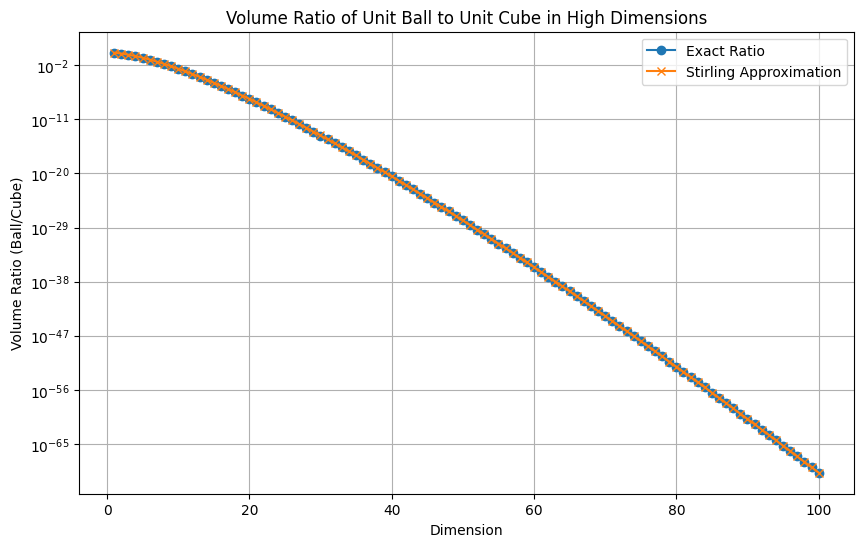

In [3]:
volume_dims = np.arange(1, 101)

ratios = [ball_cube_ratio(d) for d in volume_dims]
ratios_stirling = [ball_cube_ratio_stirling(d) for d in volume_dims]
plt.figure(figsize=(10, 6))
plt.plot(volume_dims, ratios, label='Exact Ratio', marker='o')
plt.plot(volume_dims, ratios_stirling, label='Stirling Approximation', marker='x')
plt.yscale('log')
plt.xlabel('Dimension')
plt.ylabel('Volume Ratio (Ball/Cube)')
plt.title('Volume Ratio of Unit Ball to Unit Cube in High Dimensions')
plt.legend()
plt.grid()

In [4]:
import upc_datasets as upc
import polars as pl

data = upc.load_dataset("pachamix_audio_core", download = True)
data = data.filter((pl.col("genre_top").is_not_null()) & (pl.col("genre_top")!=""))

top_genres = (
    data.group_by("genre_top")
    .len()
    .sort("len", descending=True)
    .head(4)
    .get_column("genre_top")
    .to_list()
)

data = data.filter(pl.col("genre_top").is_in(top_genres))

# Supervised algorithm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

vars = [col for col in data.columns if col not in ["genre_top","track_id","title","artist_name"]]


min_max_esc = MinMaxScaler()
standard_esc = StandardScaler()

#min_var = data.select("chroma_cens_kurtosis_01").min().item()
#max_var = data.select("chroma_cens_kurtosis_01").max().item()
#new_distribution = (data.select("chroma_cens_kurtosis_01") - min_var) / (max_var - min_var)

x = data.select(vars).to_numpy()
y = data.select("genre_top").to_numpy().ravel()

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=123)


X_train_scaled = standard_esc.fit_transform(X_train)
X_test_scaled = standard_esc.transform(X_test)


In [5]:
# Train the model and see the diff

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_preds = knn.predict(X_test_scaled)


In [6]:
from sklearn.metrics import roc_auc_score, accuracy_score
accuracy = np.mean(y_preds == y_test)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7016


In [7]:
from sklearn.linear_model import LogisticRegression

noise_dims = [0, 10, 50, 100, 200, 500, 1000,2000,4000,5000,10000]

knn_noise_rows = []
reglog_noise_rows = []

for noise_dim in noise_dims:
    if noise_dim == 0:
        X_train_noisy = X_train_scaled
        X_test_noisy = X_test_scaled
    else:
        noise_train = np.random.normal(0, 1, size=(X_train_scaled.shape[0], noise_dim))
        noise_test = np.random.normal(0, 1, size=(X_test_scaled.shape[0], noise_dim))
        X_train_noisy = np.hstack((X_train_scaled, noise_train))
        X_test_noisy = np.hstack((X_test_scaled, noise_test))

    knn_noisy = KNeighborsClassifier(n_neighbors=5)
    reglog_noisy = LogisticRegression(max_iter=1000, random_state=123)
    knn_noisy.fit(X_train_noisy, y_train)
    reglog_noisy.fit(X_train_noisy, y_train)
    y_preds_noisy = knn_noisy.predict(X_test_noisy)
    y_preds_reglog = reglog_noisy.predict(X_test_noisy)
    accuracy_noisy = np.mean(y_preds_noisy == y_test)
    accuracy_reglog = np.mean(y_preds_reglog == y_test)
    knn_noise_rows.append({"noise_dim": noise_dim, "accuracy": accuracy_noisy})
    reglog_noise_rows.append({"noise_dim": noise_dim, "accuracy": accuracy_reglog})
    print(f"Noise Dim: {noise_dim}, Accuracy: {accuracy_noisy:.4f}")
    print(f"Noise Dim: {noise_dim}, Accuracy (LogReg): {accuracy_reglog:.4f}")

Noise Dim: 0, Accuracy: 0.7016
Noise Dim: 0, Accuracy (LogReg): 0.7663
Noise Dim: 10, Accuracy: 0.6962
Noise Dim: 10, Accuracy (LogReg): 0.7660
Noise Dim: 50, Accuracy: 0.6901
Noise Dim: 50, Accuracy (LogReg): 0.7653
Noise Dim: 100, Accuracy: 0.6907
Noise Dim: 100, Accuracy (LogReg): 0.7643
Noise Dim: 200, Accuracy: 0.6791
Noise Dim: 200, Accuracy (LogReg): 0.7616
Noise Dim: 500, Accuracy: 0.6509
Noise Dim: 500, Accuracy (LogReg): 0.7547
Noise Dim: 1000, Accuracy: 0.6286
Noise Dim: 1000, Accuracy (LogReg): 0.7344
Noise Dim: 2000, Accuracy: 0.5867
Noise Dim: 2000, Accuracy (LogReg): 0.6993
Noise Dim: 4000, Accuracy: 0.5506
Noise Dim: 4000, Accuracy (LogReg): 0.6318
Noise Dim: 5000, Accuracy: 0.5426
Noise Dim: 5000, Accuracy (LogReg): 0.5988
Noise Dim: 10000, Accuracy: 0.5000
Noise Dim: 10000, Accuracy (LogReg): 0.6094


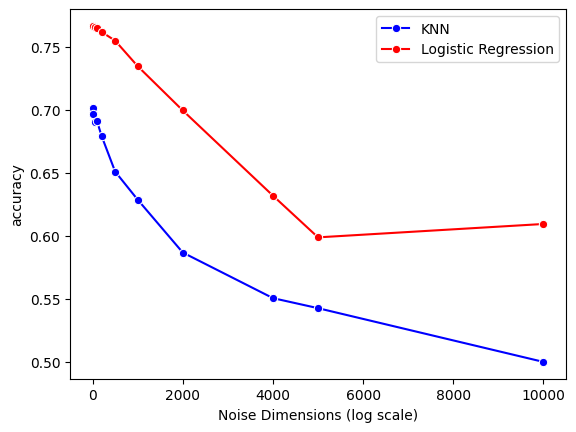

In [8]:
df_knn = pd.DataFrame(knn_noise_rows)
df_reglog = pd.DataFrame(reglog_noise_rows)

sns.lineplot(data=df_knn, x="noise_dim", y="accuracy", marker="o", label="KNN", color = "blue")
sns.lineplot(data=df_reglog, x="noise_dim", y="accuracy", marker="o", label="Logistic Regression", color = "red")
plt.xlabel("Noise Dimensions (log scale)")
plt.show()

In [9]:
from sklearn.decomposition import PCA

explained_variances = []
accuracy_pca = []

for n in [2,3,4,5,6,7,8,9,10,20,30,40,50,100,500]:
    pca = PCA(n_components=n, random_state=123)
    X_train_reduced = pca.fit_transform(X_train_scaled)
    X_test_reduced = pca.transform(X_test_scaled)
    explained_variances.append(pca.explained_variance_ratio_.sum())
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_reduced, y_train)
    y_preds = knn.predict(X_test_reduced)
    accuracy = np.mean(y_preds == y_test)
    accuracy_pca.append(accuracy)


<Axes: >

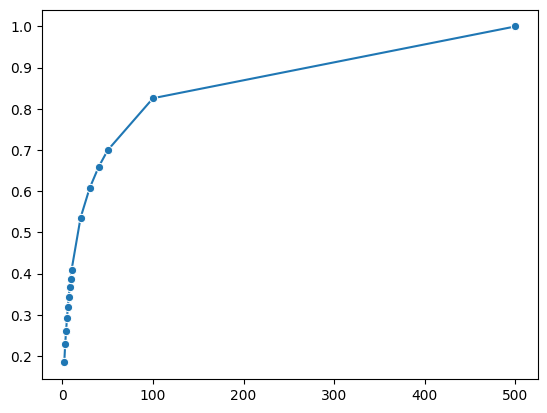

In [11]:
sns.lineplot(x=[2,3,4,5,6,7,8,9,10,20,30,40,50,100,500], y=explained_variances, marker="o")

<Axes: >

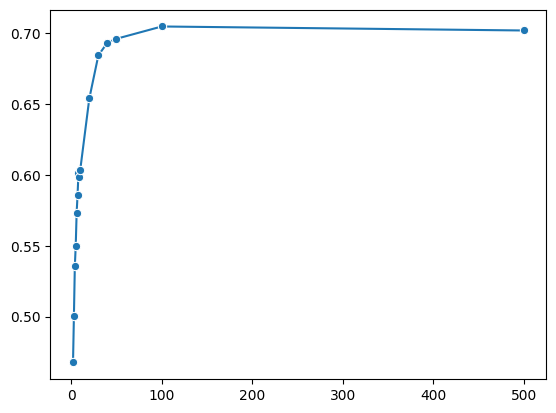

In [12]:
sns.lineplot(x=[2,3,4,5,6,7,8,9,10,20,30,40,50,100,500], y=accuracy_pca, marker="o")